### Importación de datos

Objetivo Análisis

Análisis exploratorio de datos de ventas de Alura Store, combinando visualizaciones analíticas, interpretación de métricas de negocio e insights estratégicos para apoyar la toma de decisiones basada en datos.




In [41]:
#Importación de Librerias para la ejecución
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import matplotlib.cm as cm
import numpy as np
import requests
import seaborn as sns

# URL de la API proporcionada por el challenge

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

# Transformación de url
tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,"164,300.00","6,900.00",16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.61,-74.08
1,Mesa de comedor,Muebles,"192,300.00","8,400.00",18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25,-75.56
2,Juego de mesa,Juguetes,"209,600.00","15,900.00",15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.40,-75.51
3,Microondas,Electrodomésticos,"757,500.00","41,000.00",03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.44,-76.52
4,Silla de oficina,Muebles,"335,200.00","20,200.00",07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25,-75.56


#1. Análisis de facturación



In [42]:

#Total de ingresos por tienda

ingreso1 = tienda['Precio'].sum()
ingreso2 = tienda2['Precio'].sum()
ingreso3 = tienda3['Precio'].sum()
ingreso4 = tienda4['Precio'].sum()

ingresos = {
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Ingreso Total': [ingreso1, ingreso2, ingreso3, ingreso4]
}

ingresos_df = pd.DataFrame(ingresos)

ingresos_df['Ingreso Total'] = ingresos_df['Ingreso Total'].map('{:>15,.2f}'.format)

print(ingresos_df)



     Tienda     Ingreso Total
0  Tienda 1  1,150,880,400.00
1  Tienda 2  1,116,343,500.00
2  Tienda 3  1,098,019,600.00
3  Tienda 4  1,038,375,700.00


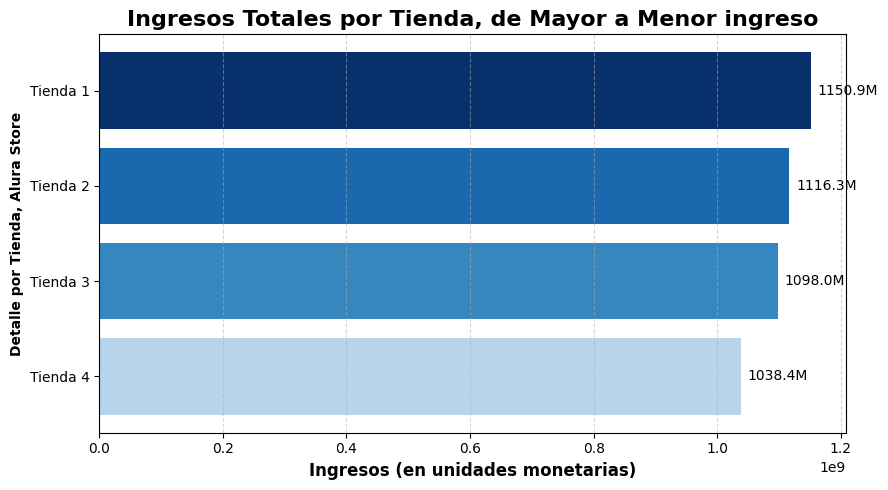

In [43]:
# Gráfico de barra para mostrar total de ventas por tienda
ingresos = [
    tienda['Precio'].sum(),
    tienda2['Precio'].sum(),
    tienda3['Precio'].sum(),
    tienda4['Precio'].sum()
]

nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

## Normalizar ingresos entre 0.3 y 1 para que no sea demasiado claro
norm = (np.array(ingresos) - np.min(ingresos)) / (np.max(ingresos) - np.min(ingresos))
norm = 0.3 + 0.7 * norm  # escala de 0.3 a 1

# Colormap
cmap = cm.Blues
colors = cmap(norm)

# Crear gráfico
plt.figure(figsize=(9,5))
bars = plt.barh(nombres_tiendas, ingresos, color=colors)

# Títulos y ejes
plt.title('Ingresos Totales por Tienda, de Mayor a Menor ingreso', fontsize=16, fontweight='bold')
plt.ylabel('Tiendas', fontsize=14, fontweight='bold')  # Eje y
plt.xlabel('Ingresos (en unidades monetarias)', fontsize=12, fontweight='bold')  # Eje x
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().invert_yaxis()
plt.ylabel('Detalle por Tienda, Alura Store', fontsize=10, fontweight='bold')  # Eje y
plt.xlabel('Ingresos (en unidades monetarias)', fontsize=12, fontweight='bold')
# Etiquetas sobre las barras
for bar, ingreso in zip(bars, ingresos):
    plt.text(bar.get_width() + bar.get_width()*0.01,
             bar.get_y() + bar.get_height()/2,
             f'{ingreso/1e6:.1f}M',
             va='center')


plt.tight_layout()
plt.savefig('Ingresos_totales_por_tienda_DMM.png')
plt.show()

# 2. Ventas por categoría

In [44]:
#Contar productos por categoria, ordena por cantidad y tienda.
def contar_productos_por_categoria(df, nombre_tienda):
    conteo = df['Categoría del Producto'].value_counts().reset_index()
    conteo.columns = ['Categoría', 'Cantidad Vendida']
    conteo['Tienda'] = nombre_tienda
    return conteo

categorias_tienda = contar_productos_por_categoria(tienda, 'Tienda 1')
categorias_tienda2 = contar_productos_por_categoria(tienda2, 'Tienda 2')
categorias_tienda3 = contar_productos_por_categoria(tienda3, 'Tienda 3')
categorias_tienda4 = contar_productos_por_categoria(tienda4, 'Tienda 4')

categorias_totales = pd.concat([categorias_tienda, categorias_tienda2, categorias_tienda3, categorias_tienda4])
by=['Tienda','Cantidad']

ascending=[True, False]
print(categorias_totales)

                 Categoría  Cantidad Vendida    Tienda
0                  Muebles               465  Tienda 1
1             Electrónicos               448  Tienda 1
2                 Juguetes               324  Tienda 1
3        Electrodomésticos               312  Tienda 1
4     Deportes y diversión               284  Tienda 1
5   Instrumentos musicales               182  Tienda 1
6                   Libros               173  Tienda 1
7  Artículos para el hogar               171  Tienda 1
0                  Muebles               442  Tienda 2
1             Electrónicos               422  Tienda 2
2                 Juguetes               313  Tienda 2
3        Electrodomésticos               305  Tienda 2
4     Deportes y diversión               275  Tienda 2
5   Instrumentos musicales               224  Tienda 2
6                   Libros               197  Tienda 2
7  Artículos para el hogar               181  Tienda 2
0                  Muebles               499  Tienda 3
1         

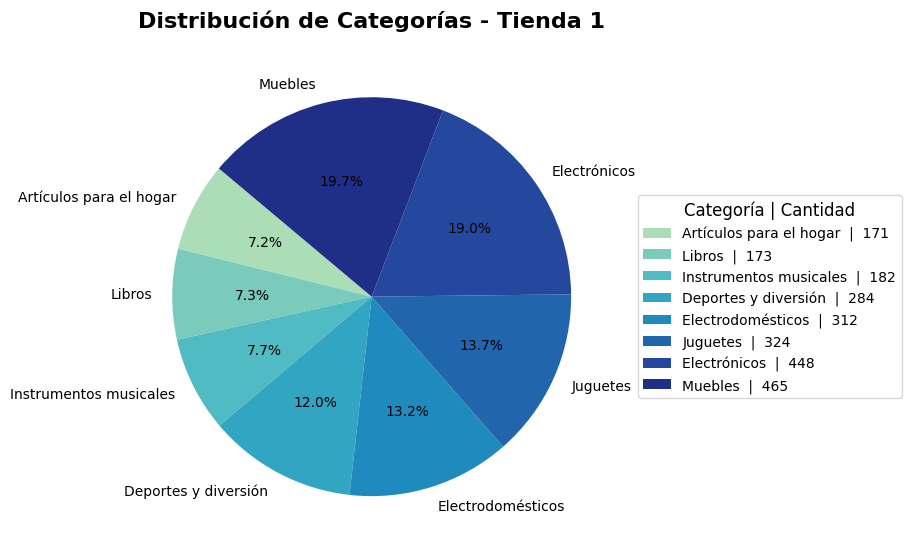


--------------------------------------------------------------------------------



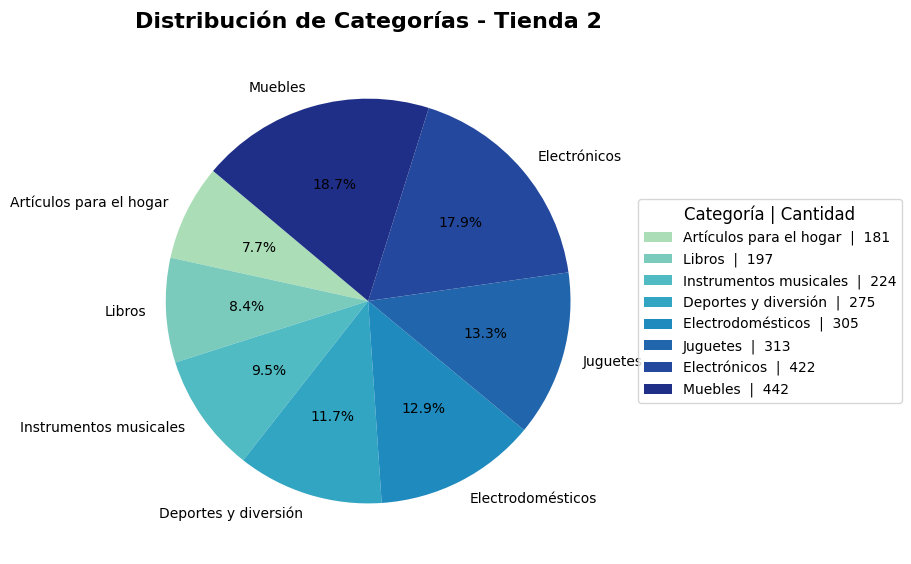


--------------------------------------------------------------------------------



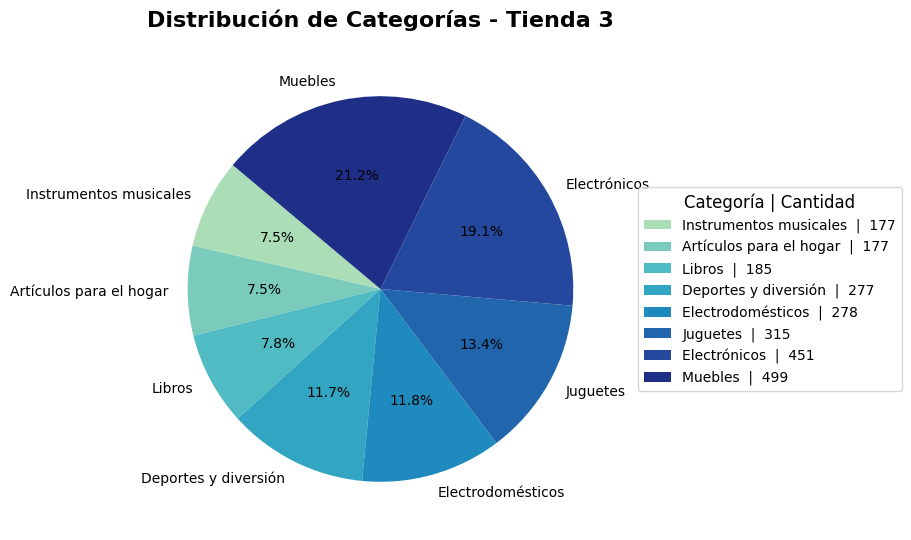


--------------------------------------------------------------------------------



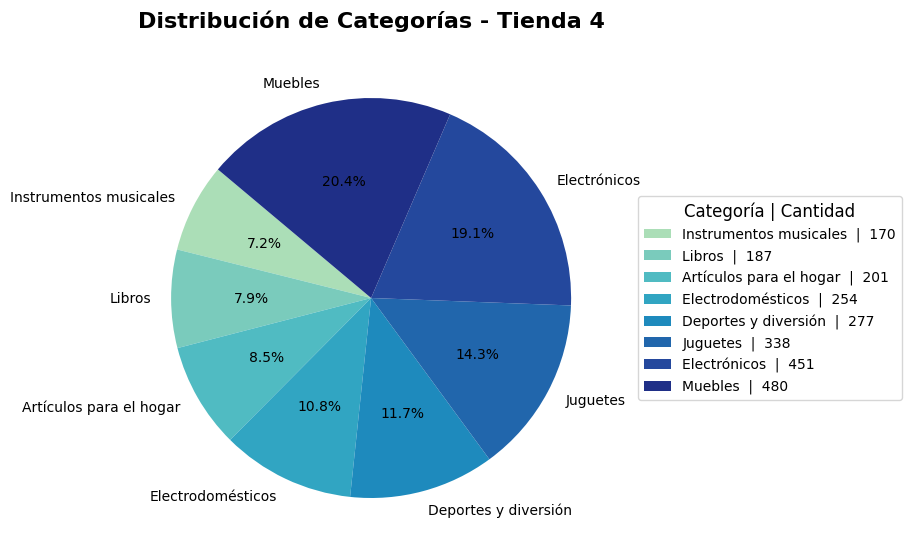


--------------------------------------------------------------------------------



In [53]:
import matplotlib.pyplot as plt
import numpy as np

tiendas = [tienda, tienda2, tienda3, tienda4]
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

for df, nombre in zip(tiendas, nombres_tiendas):

    categorias = df['Categoría del Producto'].value_counts()
    categorias = categorias.sort_values()

    # Gradiente verde azulado
    cmap = plt.cm.YlGnBu
    colors = cmap(np.linspace(0.3, 0.9, len(categorias)))

    fig, ax = plt.subplots(figsize=(9,7), constrained_layout=True)

    wedges, texts, autotexts = ax.pie(
        categorias,
        labels=categorias.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        textprops={'fontsize':10}
    )

    ax.set_title(
        f'Distribución de Categorías - {nombre}',
        fontsize=16,
        fontweight='bold',
        pad=15
    )

    # Texto de la tabla interpretativa
    etiquetas_tabla = [
        f"{cat}  |  {val}"
        for cat, val in zip(categorias.index, categorias.values)
    ]

    ax.legend(
        wedges,
        etiquetas_tabla,
        title="Categoría | Cantidad",
        title_fontsize=12,
        fontsize=10,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True
    )

    archivo_individual = f'distribucion_categorias_{nombre.lower().replace(" ", "_")}.png'

    plt.savefig(
        archivo_individual,
        dpi=400,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print("\n" + "-"*80 + "\n")

# 3. Calificación promedio de la tienda


# 4. Productos más y menos vendidos

# 5. Envío promedio por tienda